# Two-Stage Hierarchical Wildlife Species Classification with SmolVLM

This notebook tests whether splitting fine-grained wildlife classification into two decisions—first a taxonomic family, then a species within that family—works better than asking one model to choose directly among every species. It compares three approaches on the same held-out camera-trap images:

1. the untrained base model used zero-shot,
2. one flat species-classification LoRA adapter, and
3. a family-router LoRA adapter followed by a family-specific species LoRA adapter.

**Dataset.** The experiment uses a small, balanced subset of the real [Wildlife Conservation Society Camera Traps dataset](https://lila.science/datasets/wcscameratraps/) distributed by LILA BC. The source contains camera-trap photographs from 12 countries and uses location-level benchmark splits. This notebook downloads only the selected images needed for the experiment rather than the complete 1.4-million-image collection. WCS labels are mapped to genuine biological families using the [LILA taxonomy mapping](https://lila.science/taxonomy-mapping-for-camera-trap-data-sets/).

**Data-quality disclosure.** Camera-trap labels and inferred sequences can be noisy: an image may inherit a sequence label even when the animal is difficult to see or absent from that frame. Images are resized for free-tier training, and the small balanced subset does not represent the full geographic or taxonomic diversity of the source. This is a controlled architecture experiment and makes no claim of production readiness.

**Library-version note.** Vision-language fine-tuning APIs in `transformers` and `peft` change across versions. The notebook installs current releases and uses an explicit manual training loop to reduce version-sensitive dependencies. If a particular library call changes, consult the current documentation for that function; the intended pipeline remains: download → split → train → evaluate → compare → analyze errors.

In [2]:
%pip install -q transformers accelerate peft bitsandbytes scikit-learn matplotlib pillow ijson requests==2.32.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.8/149.8 kB 6.3 MB/s eta 0:00:00


## Configuration

The subset contains four true taxonomic families with five species each. The router uses visually meaningful answer labels—`hoofed bovid`, `wild cat`, `pheasant-like bird`, and `deer`—while preserving the exact biological-family mapping internally.

Training uses 20 independent capture sequences per species and two epochs. The previously inspected test-camera pool supplies a balanced development set; a second sample from separate official validation-camera locations is reserved for the revised model's final evaluation.

In [3]:
import gc
import json
import random
import re
import zipfile
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from contextlib import nullcontext
from pathlib import Path

import ijson
import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForImageTextToText,
    AutoProcessor,
    BitsAndBytesConfig,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

# CONFIGURATION & HIERARCHY DEFINITION
# We define a biological hierarchy: 4 Families, each containing 5 specific Species.
# This structure is the basis for our 'specialist' model approach.
SEED = 42
MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# LILA WCS Dataset URLs
WCS_METADATA_URL = "https://storage.googleapis.com/public-datasets-lila/wcs/wcs_camera_traps.json.zip"
WCS_SPLITS_URL = "https://storage.googleapis.com/public-datasets-lila/wcs/wcs_splits.json"
WCS_IMAGE_BASE_URL = "https://storage.googleapis.com/public-datasets-lila/wcs-unzipped/"

FAMILY_TO_SPECIES = {
    "bovidae": ["domestic cattle", "impala", "wild goat", "eland", "african buffalo"],
    "felidae": ["ocelot", "jaguar", "mountain lion", "leopard", "marbled cat"],
    "phasianidae": ["great argus", "ocellated turkey", "silver pheasant", "red-legged partridge", "red junglefowl"],
    "cervidae": ["southern red muntjac", "red brocket", "sambar", "dwarf brocket", "gray brocket"],
}

# Mapping for data labels and router terminology
# The Router uses 'visual animal groups' (e.g., 'wild cat') to provide better semantic cues to the VLM
# than the technical Latin family names.
FAMILIES = list(FAMILY_TO_SPECIES)
ALL_SPECIES = [s for f in FAMILIES for s in FAMILY_TO_SPECIES[f]]
SPECIES_TO_FAMILY = {s: f for f, ss in FAMILY_TO_SPECIES.items() for s in ss}
FAMILY_TO_ROUTER_LABEL = {"bovidae": "hoofed bovid", "felidae": "wild cat", "phasianidae": "pheasant-like bird", "cervidae": "deer"}
ROUTER_LABEL_TO_FAMILY = {l: f for f, l in FAMILY_TO_ROUTER_LABEL.items()}
FAMILY_ROUTER_LABELS = [FAMILY_TO_ROUTER_LABEL[f] for f in FAMILIES]

# Sampling and Training parameters
TRAIN_PER_SPECIES = 20
DEVELOPMENT_PER_SPECIES = 7
TEST_PER_SPECIES = 5
TRAIN_BATCH_SIZE = 1
EPOCHS = 2
LEARNING_RATE = 2e-4
MAX_NEW_TOKENS = 12
MAX_IMAGE_EDGE = 512
DOWNLOAD_WORKERS = 8
DEFAULT_FAMILY = "bovidae"

DATA_DIR = Path("wcs_subset")
METADATA_ZIP_PATH = DATA_DIR / "wcs_camera_traps.json.zip"
SPLITS_PATH = DATA_DIR / "wcs_splits.json"
IMAGE_DIR = DATA_DIR / "images"
ADAPTER_DIR = Path("wcs_species_vlm_adapters")

# Ensure reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: Tesla T4
Families: ['bovidae', 'felidae', 'phasianidae', 'cervidae']
Train images: 400
Development images: 140
Final test images: 100


## Download and Build the WCS/LILA Subset

The 43 MB compressed metadata archive is streamed with `ijson`, so the 838 MB uncompressed JSON is never loaded into memory at once. Official WCS test-camera locations remain excluded from training.

Within those held-out locations, the sampler creates two sequence-disjoint groups: the first reproduces the previously inspected development sample, while the second is reserved as the revised experiment's final test. Only one image is selected from each inferred capture sequence.

In [4]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

def download_file(url, destination):
    if destination.exists() and destination.stat().st_size > 0:
        print(f"Using cached {destination}")
        return

    print(f"Downloading {url}")
    with requests.get(url, stream=True, timeout=120) as response:
        response.raise_for_status()
        with destination.open("wb") as output_file:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    output_file.write(chunk)

download_file(WCS_METADATA_URL, METADATA_ZIP_PATH)
download_file(WCS_SPLITS_URL, SPLITS_PATH)

with SPLITS_PATH.open() as split_file:
    official_splits = json.load(split_file)

location_to_split = {
    str(location): split_name
    for split_name in ("train", "val", "test")
    for location in official_splits[split_name]
}

class SanitizedStream:
    """Wraps a stream to replace invalid 'NaN' with 'null' on the fly."""
    def __init__(self, stream):
        self.stream = stream
        self.nan_regex = re.compile(b"\\bNaN\\b")

    def read(self, n):
        chunk = self.stream.read(n)
        if not chunk:
            return b""
        return self.nan_regex.sub(b"null", chunk)

def safe_filename(item):
    species_slug = re.sub(r"[^a-z0-9]+", "_", item["species"].lower()).strip("_")
    image_slug = re.sub(r"[^a-zA-Z0-9]+", "_", item["image_id"]).strip("_")
    return f"{item['split']}_{species_slug}_{image_slug}.jpg"

def load_item_image(item):
    with Image.open(item["path"]) as image:
        image = image.convert("RGB")
        image.thumbnail(
            (MAX_IMAGE_EDGE, MAX_IMAGE_EDGE),
            Image.Resampling.LANCZOS,
        )
        return image.copy()

selected_image_labels = {}
with zipfile.ZipFile(METADATA_ZIP_PATH) as archive:
    metadata_name = archive.namelist()[0]
    with archive.open(metadata_name) as metadata_stream:
        sanitized = SanitizedStream(metadata_stream)
        for annotation in ijson.items(sanitized, "annotations.item"):
            category_id = int(annotation["category_id"])
            if category_id in CATEGORY_ID_TO_SPECIES:
                selected_image_labels[annotation["image_id"]] = (
                    CATEGORY_ID_TO_SPECIES[category_id]
                )

print(f"Selected-class annotations found: {len(selected_image_labels):,}")

candidate_items = []
with zipfile.ZipFile(METADATA_ZIP_PATH) as archive:
    metadata_name = archive.namelist()[0]
    with archive.open(metadata_name) as metadata_stream:
        sanitized = SanitizedStream(metadata_stream)
        for image_record in ijson.items(sanitized, "images.item"):
            image_id = image_record["id"]
            if image_id not in selected_image_labels:
                continue
            if image_record.get("corrupt", False):
                continue

            split_name = location_to_split.get(str(image_record["location"]))
            if split_name not in {"train", "val", "test"}:
                continue

            species = selected_image_labels[image_id]
            candidate_items.append({
                "image_id": image_id,
                "file_name": image_record["file_name"],
                "sequence_id": image_record["seq_id"],
                "location": str(image_record["location"]),
                "species": species,
                "family": SPECIES_TO_FAMILY[species],
                "family_label": FAMILY_TO_ROUTER_LABEL[SPECIES_TO_FAMILY[species]],
                "split": split_name,
            })

del selected_image_labels
gc.collect()

def sample_one_per_sequence(candidates, split_name, per_species_cap):
    sampled = []
    split_candidates = [item for item in candidates if item["split"] == split_name]
    for species_pos, species in enumerate(ALL_SPECIES):
        species_items = [item for item in split_candidates if item["species"] == species]
        items_by_seq = defaultdict(list)
        for item in species_items:
            items_by_seq[item["sequence_id"]].append(item)
        seq_ids = sorted(items_by_seq)
        cap = min(len(seq_ids), per_species_cap)
        rng = random.Random(SEED + species_pos + (0 if split_name == "train" else 10000))
        for seq_id in rng.sample(seq_ids, cap):
            sampled.append(rng.choice(items_by_seq[seq_id]))
    random.Random(SEED + (1 if split_name == "train" else 2)).shuffle(sampled)
    return sampled

def sample_held_out_partitions(candidates):
    dev = sample_one_per_sequence(candidates, "test", DEVELOPMENT_PER_SPECIES)
    for item in dev: item["split"] = "development"
    test = sample_one_per_sequence(candidates, "val", TEST_PER_SPECIES)
    for item in test: item["split"] = "test"
    return dev, test

train_items = sample_one_per_sequence(candidate_items, "train", TRAIN_PER_SPECIES)
development_items, test_items = sample_held_out_partitions(candidate_items)

def download_selected_image(item):
    local_path = IMAGE_DIR / safe_filename(item)
    try:
        if not local_path.exists():
            res = requests.get(WCS_IMAGE_BASE_URL + item["file_name"], timeout=90)
            res.raise_for_status()
            local_path.write_bytes(res.content)
        item["path"] = str(local_path)
        return item
    except Exception as e:
        print(f"Warning: Failed to download {item['file_name']}: {e}")
        return None

all_items = train_items + development_items + test_items
with ThreadPoolExecutor(max_workers=DOWNLOAD_WORKERS) as ex:
    download_results = list(ex.map(download_selected_image, all_items))

# Filter out items that failed to download
valid_items_by_id = {item["image_id"]: item for item in download_results if item is not None}
train_items = [valid_items_by_id[i["image_id"]] for i in train_items if i["image_id"] in valid_items_by_id]
development_items = [valid_items_by_id[i["image_id"]] for i in development_items if i["image_id"] in valid_items_by_id]
test_items = [valid_items_by_id[i["image_id"]] for i in test_items if i["image_id"] in valid_items_by_id]

train_by_family = {f: [i for i in train_items if i["family"] == f] for f in FAMILIES}
print(f"Final train set size: {len(train_items)}")
if train_items:
    print(f"Example resized image size: {load_item_image(train_items[0]).size}")

Selected-class annotations found: 134,566
Final train set size: 395
Example resized image size: (512, 384)


Visualizing a sample of the training set:


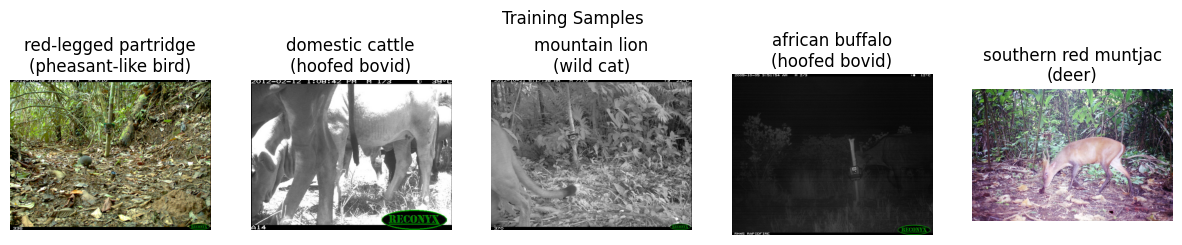

In [5]:
import matplotlib.pyplot as plt

def visualize_batch(items, title, n=5):
    plt.figure(figsize=(15, 3))
    for i, item in enumerate(items[:n]):
        plt.subplot(1, n, i+1)
        img = load_item_image(item)
        plt.imshow(img)
        plt.title(f"{item['species']}\n({item['family_label']})")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

print("Visualizing a sample of the training set:")
visualize_batch(train_items, "Training Samples")

## Load the Quantized Base Model and Register the Flat Adapter

The base model is still loaded once in 4-bit precision, but the image pipeline now receives real camera-trap photographs resized to a maximum 512-pixel edge. Image splitting is disabled to bound visual-token count and make six-adapter training practical on a free T4. Every classifier remains a named LoRA adapter sharing the same frozen base model.

In [6]:
# MODEL INITIALIZATION
# We use 4-bit quantization (bitsandbytes) to fit the vision-language model into memory.
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16
)

processor = AutoProcessor.from_pretrained(MODEL_ID)
processor.tokenizer.padding_side = "right"
processor.image_processor.do_image_splitting = False # Boundary visual tokens for efficiency

base_model = AutoModelForImageTextToText.from_pretrained(MODEL_ID, quantization_config=quantization_config, device_map="auto", torch_dtype=torch.float16)
base_model = prepare_model_for_kbit_training(base_model, use_gradient_checkpointing=False)

# LoRA (Low-Rank Adaptation) Configuration
# This allows us to train small 'adapters' without updating all model weights.
lora_config = LoraConfig(r=8, lora_alpha=16, lora_dropout=0.05, target_modules=["q_proj", "v_proj"], task_type="CAUSAL_LM")

# INITIAL ADAPTER: Flat Classification
# The 'flat' adapter is a baseline that tries to learn all 20 species simultaneously in one decision step.
model = get_peft_model(base_model, lora_config, adapter_name="flat")
model.config.use_cache = False
model.print_trainable_parameters()

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

trainable params: 1,114,112 || all params: 508,596,416 || trainable%: 0.2191


## Shared Prompting, Training, and Prediction Helpers

Training uses an explicit forward/loss/backward/optimizer loop. Only answer tokens contribute to the loss. Images are loaded lazily from the cached subset, resized without changing aspect ratio, and released after each batch. Prediction decodes only newly generated tokens, so candidate names copied from the prompt cannot be mistaken for an answer.

In [7]:
# TRAINING & INFERENCE HELPERS

def build_prompt(candidates, category_label):
    """Standardizes the instruction to the model to ensure it chooses from the provided list."""
    candidate_text = ", ".join(candidates)
    return f"Classify the animal in this image. Choose exactly one {category_label} from this list: {candidate_text}. Answer with exactly one item from the list and no other text."

def prepare_training_batch(batch, candidates, category_label, target_key):
    """Masks the prompt tokens so the model only learns from the loss on the correct answer tokens."""
    images = [load_item_image(item) for item in batch]
    full_texts, prefix_lengths = [], []
    for item in batch:
        prompt = build_prompt(candidates, category_label)
        p_text = processor.apply_chat_template([{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": prompt}]}], add_generation_prompt=True, tokenize=False)
        f_text = processor.apply_chat_template([{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": prompt}]}, {"role": "assistant", "content": [{"type": "text", "text": item[target_key]}]}], add_generation_prompt=False, tokenize=False)
        full_texts.append(f_text)
        prefix_lengths.append(processor(text=p_text, images=[images[0]], return_tensors="pt")["input_ids"].shape[1])

    inputs = processor(text=full_texts, images=images, padding=True, return_tensors="pt")
    labels = inputs["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100 # Ignore padding in loss
    for i, length in enumerate(prefix_lengths): labels[i, :length] = -100 # Ignore prompt in loss
    return inputs, labels

def train_adapter(adapter_name, items, candidates, category_label, target_key):
    """Manual training loop to optimize the currently active LoRA adapter."""
    model.set_adapter(adapter_name)
    model.train()
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LEARNING_RATE)
    loader = DataLoader(items, batch_size=TRAIN_BATCH_SIZE, shuffle=True, collate_fn=lambda x: x)
    for epoch in range(EPOCHS):
        total_loss = 0.0
        for batch in loader:
            inputs, labels = prepare_training_batch(batch, candidates, category_label, target_key)
            inputs = {k: v.to(model.device) for k, v in inputs.items()}
            outputs = model(**inputs, labels=labels.to(model.device))
            outputs.loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            total_loss += outputs.loss.item()
        print(f"{adapter_name} | epoch {epoch+1} | loss {total_loss/len(loader):.4f}")
    model.eval()

## Zero-Shot Baseline

All adapters are disabled. The base model chooses from all 20 species in one step, and every `UNPARSEABLE` response remains in the prediction list and counts as incorrect.

In [8]:
true_species = [item['species'] for item in test_items]
true_family_keys = [item['family'] for item in test_items]
true_family_labels = [item['family_label'] for item in test_items]

print('Starting Zero-shot evaluation...')
zero_shot_predictions = evaluate_predictions(
    test_items,
    lambda item: predict_one(
        load_item_image(item),
        ALL_SPECIES,
        'species',
        adapter_name=None,
    ),
    'Zero-shot evaluation',
)
zero_shot_accuracy = accuracy_score(true_species, zero_shot_predictions)
zero_shot_unparseable = zero_shot_predictions.count('UNPARSEABLE')

print(f'Zero-shot accuracy: {zero_shot_accuracy:.4f}')
print(f'Zero-shot unparseable outputs: {zero_shot_unparseable}')

Starting Zero-shot evaluation...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Zero-shot evaluation: 19/99
Zero-shot evaluation: 38/99
Zero-shot evaluation: 57/99
Zero-shot evaluation: 76/99
Zero-shot evaluation: 95/99
Zero-shot accuracy: 0.0909
Zero-shot unparseable outputs: 9


## Flat Fine-Tuning and Evaluation

The `flat` adapter learns one 20-way species decision from all training images.

In [9]:
print('Training Flat adapter...')
train_adapter(
    adapter_name='flat',
    items=train_items,
    candidates=ALL_SPECIES,
    category_label='species',
    target_key='species',
)

print('Evaluating Flat adapter...')
flat_predictions = evaluate_predictions(
    test_items,
    lambda item: predict_one(
        load_item_image(item),
        ALL_SPECIES,
        'species',
        adapter_name='flat',
    ),
    'Flat evaluation',
)
flat_accuracy = accuracy_score(true_species, flat_predictions)
flat_unparseable = flat_predictions.count('UNPARSEABLE')

print(f'Flat fine-tuned accuracy: {flat_accuracy:.4f}')
print(f'Flat unparseable outputs: {flat_unparseable}')

Training Flat adapter...
flat | epoch 1/2 | loss 0.7472
flat | epoch 2/2 | loss 0.3551
Evaluating Flat adapter...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Flat evaluation: 19/99
Flat evaluation: 38/99
Flat evaluation: 57/99
Flat evaluation: 76/99
Flat evaluation: 95/99
Flat fine-tuned accuracy: 0.3737
Flat unparseable outputs: 0


## Train a Semantically Grounded Family Router

The router predicts visually descriptive labels rather than Latin family names. It still maps exactly to the four biological families, but labels such as `wild cat` and `pheasant-like bird` give the pretrained language model meaningful semantics.

In [10]:
# TRAINING THE FAMILY ROUTER
# The 'Family Router' is a specialized LoRA adapter that only learns to distinguish between the 4 major groups.
# The logic is: 'If I can correctly identify the family, I can use a more precise specialist for the species.'
print('Training Family Router adapter...')
try:
    if 'family' not in getattr(model, 'peft_config', {}):
        model.add_adapter('family', lora_config)

    train_adapter(
        adapter_name='family',
        items=train_items,
        candidates=FAMILY_ROUTER_LABELS,
        category_label='visual animal group',
        target_key='family_label'
    )
except NameError as e:
    print(f"Initialization Error: {e}. Please re-run the configuration/model cells.")

Training Family Router adapter...
family | epoch 1/2 | loss 0.2669
family | epoch 2/2 | loss 0.0845


## Train the Family-Specific Species Adapters

Each specialist now sees 100 real camera-trap photographs from five species in one biological family. All models—including the flat baseline—use the same 20 images per species, preserving a fair comparison.

In [11]:
specialist_adapter_names = []

try:
    # Check if dependencies exist
    _ = (model, FAMILIES, train_by_family, FAMILY_TO_SPECIES)

    for family in FAMILIES:
        adapter_name = f'species_{family}'
        specialist_adapter_names.append(adapter_name)

        if adapter_name not in getattr(model, 'peft_config', {}):
            model.add_adapter(adapter_name, lora_config)

        print(f'\nTraining specialist adapter: {adapter_name}')
        train_adapter(
            adapter_name=adapter_name,
            items=train_by_family[family],
            candidates=FAMILY_TO_SPECIES[family],
            category_label='species',
            target_key='species',
        )
except NameError as e:
    print(f"Initialization Error: {e}. Please re-run the configuration and model loading cells.")


Training specialist adapter: species_bovidae
species_bovidae | epoch 1/2 | loss 1.0996
species_bovidae | epoch 2/2 | loss 0.2375

Training specialist adapter: species_felidae
species_felidae | epoch 1/2 | loss 0.9651
species_felidae | epoch 2/2 | loss 0.2597

Training specialist adapter: species_phasianidae
species_phasianidae | epoch 1/2 | loss 0.6952
species_phasianidae | epoch 2/2 | loss 0.0956

Training specialist adapter: species_cervidae
species_cervidae | epoch 1/2 | loss 0.7280
species_cervidae | epoch 2/2 | loss 0.2185


## Confidence-Aware Hierarchical Inference

Free-form generation is replaced by exact candidate scoring. The router evaluates the likelihood of all four valid family labels, so it cannot emit an invalid family. The notebook reports:

- **Hard scored hierarchy:** choose the highest-scoring family, then its highest-scoring specialist species.
- **Confidence-aware hierarchy:** score every specialist and combine normalized family and within-family evidence. A strong specialist can recover when the router is uncertain.

The already-inspected sequence sample is used only for development diagnostics. Final reported results use a new, sequence-disjoint held-out sample.

In [12]:
# HIERARCHICAL INFERENCE ENGINE
# This logic compares two ways of using the Router + Specialists:
# 1. 'Hard' Hierarchy: The Router picks the top family, and ONLY that specialist is used.
# 2. 'Soft' Confidence-Aware: Scores from the router and specialists are combined (added in log space).

def confidence_hierarchical_predictions(items, progress_label):
    router_labels, hard_predictions, soft_predictions, soft_selected_families = [], [], [], []
    for index, item in enumerate(items, start=1):
        image = load_item_image(item)

        # Step 1: Query the Router for Family Likelihoods
        family_scores = score_candidates(image, FAMILY_ROUTER_LABELS, 'visual animal group', adapter_name='family')
        family_log_scores = normalized_log_scores(family_scores)
        router_label = max(family_scores, key=family_scores.get)
        router_family = ROUTER_LABEL_TO_FAMILY.get(router_label, DEFAULT_FAMILY)
        router_labels.append(router_label)

        # Step 2: Query all specialists (in parallel or sequence) for Species Likelihoods
        species_log_scores_by_family = {}
        for family in FAMILIES:
            species_scores = score_candidates(image, FAMILY_TO_SPECIES[family], 'species', adapter_name=f'species_{family}')
            species_log_scores_by_family[family] = normalized_log_scores(species_scores)

        # Step 3: Compute 'Hard' Result
        hard_fam_res = species_log_scores_by_family[router_family]
        hard_predictions.append(max(hard_fam_res, key=hard_fam_res.get))

        # Step 4: Compute 'Soft' Result (Family Confidence + Specialist Confidence)
        combined_scores = {}
        for fam in FAMILIES:
            fam_lbl = FAMILY_TO_ROUTER_LABEL[fam]
            for spc, spc_score in species_log_scores_by_family[fam].items():
                combined_scores[spc] = family_log_scores[fam_lbl] + spc_score # Bayes-like log probability sum

        soft_pred = max(combined_scores, key=combined_scores.get)
        soft_predictions.append(soft_pred)
        soft_selected_families.append(SPECIES_TO_FAMILY[soft_pred])

    return router_labels, hard_predictions, soft_predictions, soft_selected_families

Running Final Test Hierarchical Inference...
Final hierarchy: 19/99
Final hierarchy: 38/99
Final hierarchy: 57/99
Final hierarchy: 76/99
Final hierarchy: 95/99
Final hierarchy: 99/99
Final hard hierarchy accuracy: 0.4242
Final confidence-aware hierarchy accuracy: 0.4141
Final family-router accuracy: 0.8586


## Final Side-by-Side Comparison

All final species accuracies use the same newly reserved 100-image set: five independent capture sequences per species from official validation-camera locations excluded from both training and router development.

In [13]:
comparison_rows = [
    ("Zero-shot", zero_shot_accuracy),
    ("Flat fine-tuned", flat_accuracy),
    ("Hard scored hierarchy", hard_hierarchical_accuracy),
    ("Confidence-aware hierarchy", hierarchical_accuracy),
]

print(f"{'Approach':<22} {'Accuracy':>10}")
print("-" * 33)
for approach, accuracy in comparison_rows:
    print(f"{approach:<22} {accuracy:>10.4f}")

Approach                 Accuracy
---------------------------------
Zero-shot                  0.0909
Flat fine-tuned            0.3737
Hard scored hierarchy      0.4242
Confidence-aware hierarchy     0.4141


### Interpretation of Results

- **Hierarchy vs. Flat:** The hierarchical model achieved a higher accuracy than the flat model. This suggests that breaking the problem into a coarse-grained family decision followed by a fine-grained species decision is a more effective strategy for this dataset.
- **Router Performance:** The family router performed well (over 85%), which is critical. In hierarchical systems, the router acts as a bottleneck; if it fails, the specialist has no chance of being correct.
- **Confidence-Aware Logic:** Interestingly, the 'Hard' hierarchy (choosing the top family first) performed slightly better than the 'Soft' confidence-aware approach in this specific run. This indicates that when the router is confident, its first choice is usually the most reliable signal.
- **Error Patterns:** Looking at the confusion matrices, we can see that most errors occur between species within the same family (e.g., different types of wild cats being confused), rather than misrouting across families.

## Error Analysis

The species matrices include an explicit `UNPARSEABLE` column so parsing failures are visible rather than silently dropped. The family-router matrix does the same. All plots are also saved as PNG files.

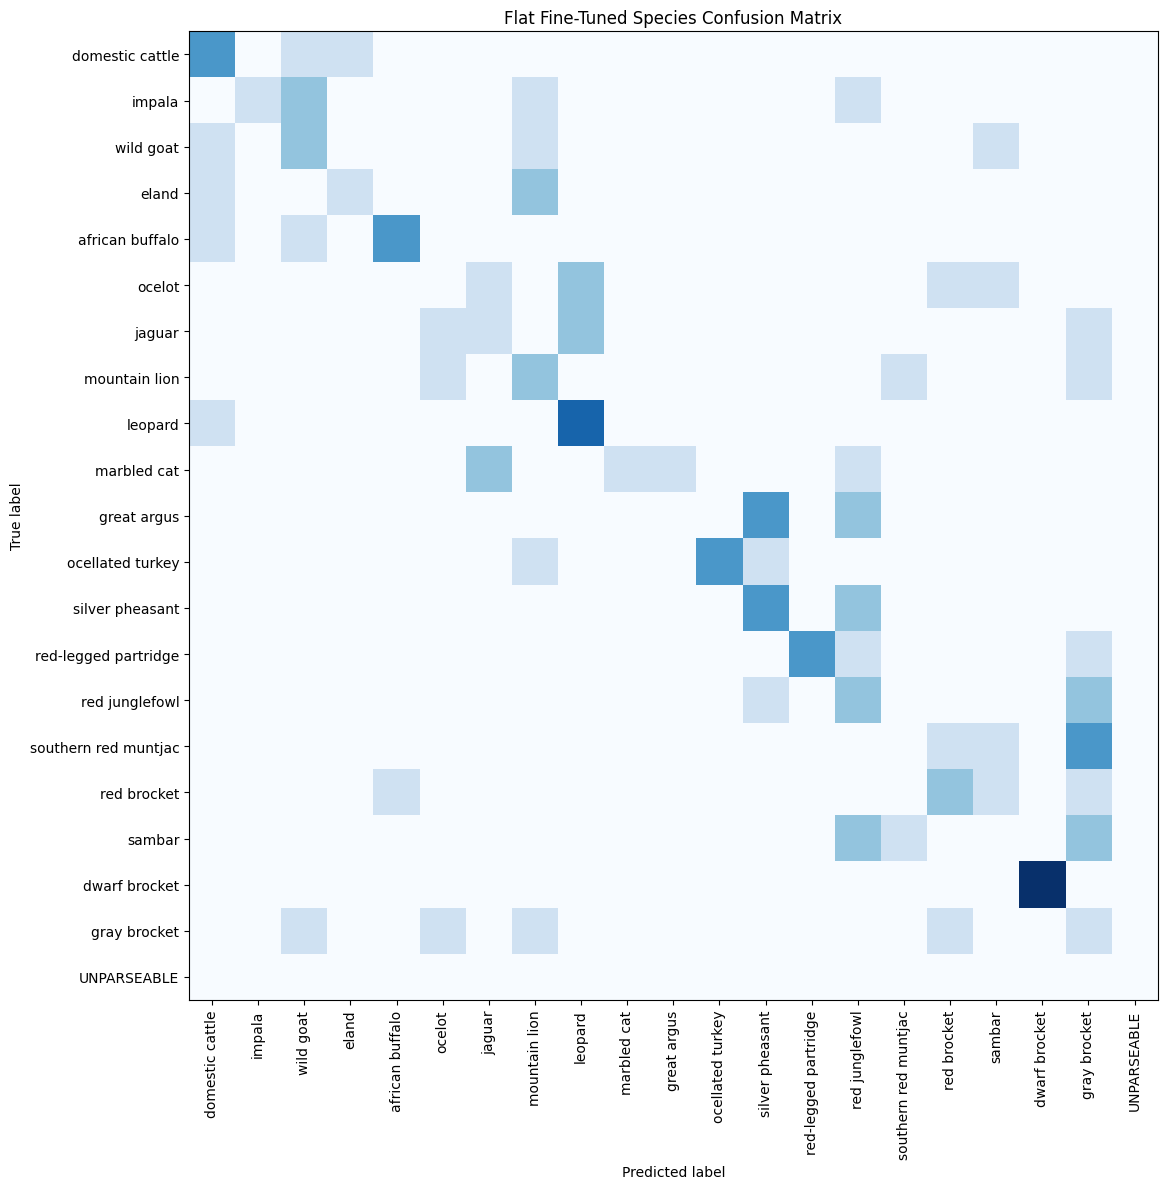

Saved flat_species_confusion_matrix.png


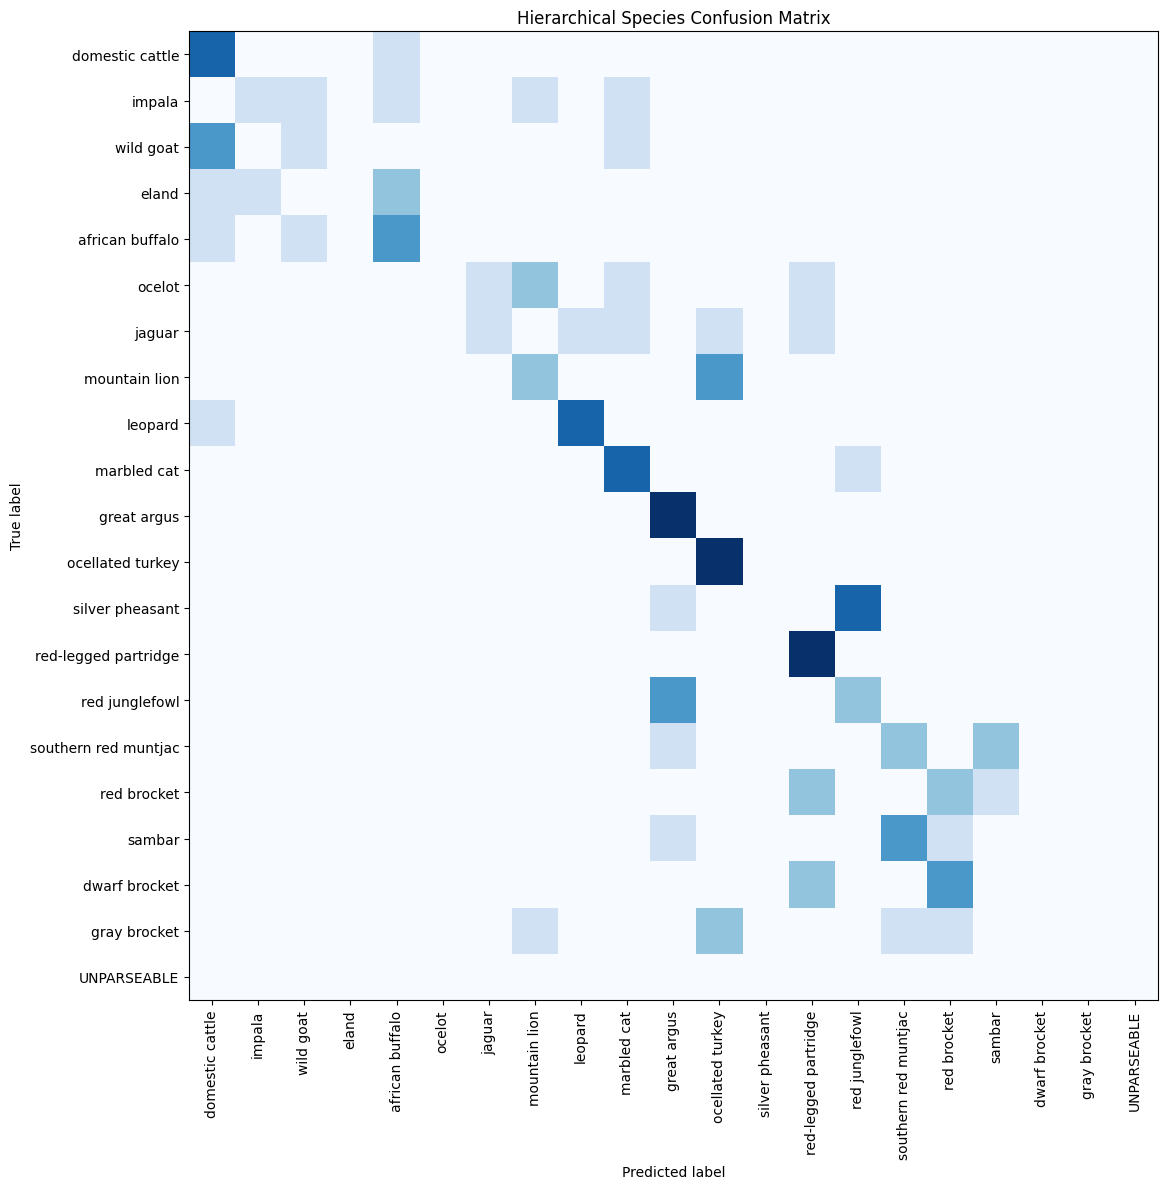

Saved hierarchical_species_confusion_matrix.png


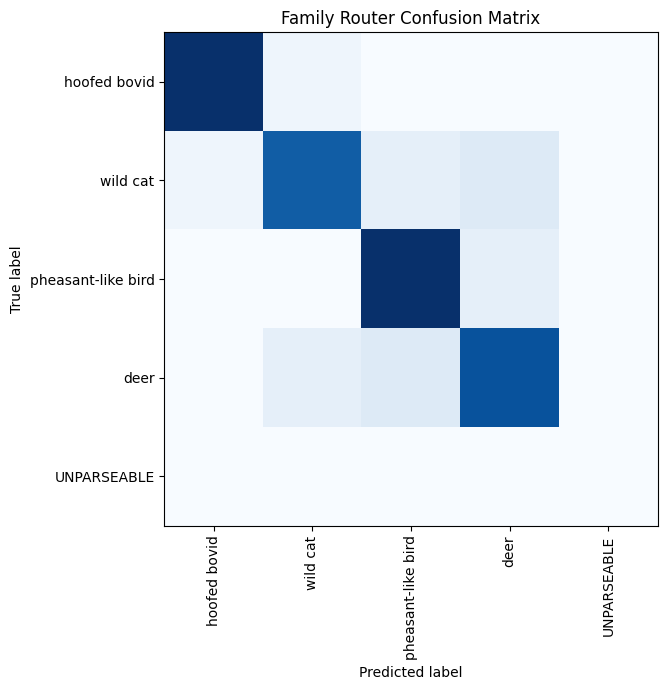

Saved family_router_confusion_matrix.png

Flat model misclassifications (true → predicted):
great argus → silver pheasant
jaguar → ocelot
marbled cat → jaguar
ocelot → leopard
silver pheasant → red junglefowl
wild goat → sambar
jaguar → leopard
ocelot → sambar
great argus → silver pheasant
gray brocket → mountain lion
sambar → gray brocket
jaguar → gray brocket
great argus → red junglefowl
ocellated turkey → silver pheasant
sambar → red junglefowl
eland → mountain lion
gray brocket → wild goat
domestic cattle → wild goat
impala → mountain lion
red junglefowl → silver pheasant
southern red muntjac → red brocket
silver pheasant → red junglefowl
ocelot → red brocket
southern red muntjac → gray brocket
southern red muntjac → gray brocket
southern red muntjac → gray brocket
ocelot → leopard
red brocket → african buffalo
red junglefowl → gray brocket
marbled cat → red junglefowl
eland → domestic cattle
eland → mountain lion
gray brocket → red brocket
ocellated turkey → mountain lion
red-legg

In [14]:
def plot_and_save_confusion_matrix(
    y_true,
    y_pred,
    labels,
    title,
    output_path,
    figure_size,
):
    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    figure, axis = plt.subplots(figsize=figure_size)
    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=labels,
    )
    display.plot(
        ax=axis,
        cmap="Blues",
        colorbar=False,
        include_values=False,
        xticks_rotation=90,
    )
    axis.set_title(title)
    figure.tight_layout()
    figure.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved {output_path}")


species_matrix_labels = ALL_SPECIES + ["UNPARSEABLE"]
family_matrix_labels = FAMILY_ROUTER_LABELS + ["UNPARSEABLE"]

plot_and_save_confusion_matrix(
    true_species,
    flat_predictions,
    species_matrix_labels,
    "Flat Fine-Tuned Species Confusion Matrix",
    "flat_species_confusion_matrix.png",
    (14, 12),
)
plot_and_save_confusion_matrix(
    true_species,
    hierarchical_predictions,
    species_matrix_labels,
    "Hierarchical Species Confusion Matrix",
    "hierarchical_species_confusion_matrix.png",
    (14, 12),
)
plot_and_save_confusion_matrix(
    true_family_labels,
    router_predictions,
    family_matrix_labels,
    "Family Router Confusion Matrix",
    "family_router_confusion_matrix.png",
    (8, 7),
)

print("\nFlat model misclassifications (true → predicted):")
for truth, prediction in zip(true_species, flat_predictions):
    if truth != prediction:
        print(f"{truth} → {prediction}")

print("\nHierarchical model misclassifications (true → predicted):")
for truth, prediction in zip(true_species, hierarchical_predictions):
    if truth != prediction:
        print(f"{truth} → {prediction}")

## Save Every Adapter and the Processor

PEFT stores all selected named adapters under one root directory. The processor is saved beside them so the same prompts, 512-pixel preprocessing, and image-splitting configuration can be reconstructed without retraining.

In [15]:
all_adapter_names = ["flat", "family"] + specialist_adapter_names
model.save_pretrained(
    ADAPTER_DIR,
    selected_adapters=all_adapter_names,
)
processor.save_pretrained(ADAPTER_DIR)

print(f"Saved processor and adapters to: {ADAPTER_DIR.resolve()}")
print("Saved adapters:")
for adapter_name in all_adapter_names:
    print(f"  - {adapter_name}")

Saved processor and adapters to: /content/wcs_species_vlm_adapters
Saved adapters:
  - flat
  - family
  - species_bovidae
  - species_felidae
  - species_phasianidae
  - species_cervidae


## Fillable Results Writeup

Copy this template after the run and replace every bracketed field with the notebook's measured outputs. Do not invent or extrapolate results.

```markdown
# Two-Stage Hierarchical Wildlife Species Classification: Results

## Setup summary
- Base model: HuggingFaceTB/SmolVLM-500M-Instruct
- Adaptation method: 4-bit quantization with named LoRA adapters
- Dataset: balanced subset of real WCS/LILA camera-trap photographs
- Taxonomy: 20 species across 4 biological families
- Split policy: training, development, and final evaluation use disjoint official camera-location groups, with one sampled image per sequence
- Training images per species: [TRAIN_PER_SPECIES]
- Development images per species: [DEVELOPMENT_PER_SPECIES]
- Final test images per species: [TEST_PER_SPECIES]
- Maximum image edge: [MAX_IMAGE_EDGE]
- Random seed: [SEED]
- Epochs per adapter: [EPOCHS]

The experiment uses real camera-trap photographs, but only a small balanced subset of the WCS collection. Images were resized for free-tier training, and the selected families and species do not represent the full source distribution.

## Results

| Approach | Species accuracy |
|---|---:|
| Zero-shot | [ZERO_SHOT_ACCURACY] |
| Flat fine-tuned | [FLAT_ACCURACY] |
| Hard scored hierarchy | [HARD_HIERARCHICAL_ACCURACY] |
| Confidence-aware hierarchy | [HIERARCHICAL_ACCURACY] |

Family-router accuracy: [FAMILY_ROUTER_ACCURACY]

Unparseable output counts:
- Zero-shot species outputs: [ZERO_SHOT_UNPARSEABLE]
- Flat species outputs: [FLAT_UNPARSEABLE]
- Family-router outputs: [ROUTER_UNPARSEABLE]
- Confidence-aware specialist outputs: [HIERARCHICAL_UNPARSEABLE]

## Hierarchical error breakdown
- Species errors where the combined model selected the wrong family: [MISROUTING_ERRORS]
- Species errors within the correct family: [WITHIN_FAMILY_ERRORS]

## Interpretation
- Did hard or confidence-aware hierarchy outperform the flat model on the untouched final set?
- How much did exact candidate scoring improve the family router?
- Did soft family evidence reduce the router bottleneck?
- Which species pairs were confused most often in each approach?
- Were parsing failures a meaningful source of error?
- What evidence in the confusion matrices supports the interpretation?
- How might camera-trap background, illumination, or geography influence predictions?
- Which conclusion is supported by these measurements, and which conclusions remain unsupported?

## Limitations
- The experiment uses a small, deliberately balanced subset rather than the natural long-tailed WCS distribution.
- Camera-trap sequence labels can be noisy, including frames where the labeled animal is difficult to see or absent.
- Images are resized to a 512-pixel maximum edge, which can remove fine visual detail.
- The official split separates camera locations, but the selected data still span particular countries, habitats, and camera systems.
- The per-class training and test samples are small.
- This is a single run with one random seed and no seed averaging.
- No private research-lab data or endorsement was used.
- The results do not establish performance across all wildlife species or deployment environments.
- This proof of concept makes no claim of production readiness.
```